<a href="https://colab.research.google.com/github/YourChair/CSE-110-LAB-1/blob/main/Copy_of_CSE151A_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1

In [1]:
!git clone https://github.com/ucsd-cse151a-ss124/hw1.git

Cloning into 'hw1'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 29 (delta 12), reused 5 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 20.23 KiB | 4.05 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In this assignment, we will be exploring the car dataset and analyzing their fuel efficiency. <br >
Specifically, we will do some exploratory analysis with visualizations, then we will build a model for Simple Linear Regression, a model for Polynomial Regression, and one model for Logistic Regression. <br >
**The given dataset is already modified and cleaned**, but you can find [the original information here.](https://archive.ics.uci.edu/ml/datasets/auto+mpg).

## Dataset Attribute Information

1. **mpg**: Miles per gallon. This is one primary measurement for car fuel efficiency.
2. **displacement** : The cylinder volumes in cubic inches.
3. **horsepower** : Engine power.
4. **weight** : In pounds.
5. **acceleration** : The elapsed time in seconds to go from 0 to 60mph.
6. **origin** : Region of origin.

### Libraries that can be used: numpy, pandas, scikit-learn, seaborn, plotly, matplotlib
Any libraries used in the discussion materials are also allowed.

#### Other Notes
 - Don't worry about not being able to achieve high accuracy, it is neither the goal nor the grading standard of **this** assignment. <br >
 - If not specified, you are not required to do hyperparameter tuning, but feel free to do so if you'd like.
 - Discussion materials should be helpful for doing the assignments.

# Exercises
## Exercise 1 - Exploratory Analysis (20 points in total)

### Exercise 1.1 - Correlation Matrix (10 points)
Generate a Pearson [correlation matrix plot](https://heartbeat.fritz.ai/seaborn-heatmaps-13-ways-to-customize-correlation-matrix-visualizations-f1c49c816f07) in the form of a heatmap. See the link to have an idea about what this visualization should look like. <br >
After generating the plot, answer the following question: <br >
**If we are going to predict ``mpg`` in Simple Linear Regression(i.e., $y=ax+b$), which attribute are you most UNLIKELY to pick as the independent variable? Explain why.**

Requirements & notes
 - When computing correlation, make sure to drop the column ``origin`` to avoid errors.
 - The computed correlation values should be shown on the plot.
 - Use a diverging color scale with the color range being \[-1, 1\] and center being 0 (if applicable).

[['mpg' 'displacement' 'horsepower' 'weight' 'acceleration']
 ['18.0' '307.0' '130.0' '3504.0' '12.0']
 ['15.0' '350.0' '165.0' '3693.0' '11.5']
 ...
 ['32.0' '135.0' '84.0' '2295.0' '11.6']
 ['28.0' '120.0' '79.0' '2625.0' '18.6']
 ['31.0' '119.0' '82.0' '2720.0' '19.4']]
[['18.0' '307.0' '130.0' '3504.0' '12.0']
 ['15.0' '350.0' '165.0' '3693.0' '11.5']
 ['18.0' '318.0' '150.0' '3436.0' '11.0']
 ...
 ['32.0' '135.0' '84.0' '2295.0' '11.6']
 ['28.0' '120.0' '79.0' '2625.0' '18.6']
 ['31.0' '119.0' '82.0' '2720.0' '19.4']]


<Axes: >

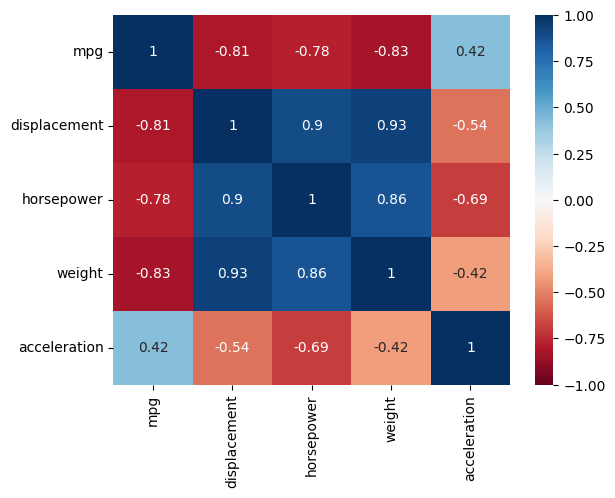

In [2]:
#importing all the libraries needed
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv

mpg1 = []
with open('hw1/auto-mpg.csv', mode ='r') as file:
  csvFile = csv.reader(file)
  for line in csvFile:
    mpg1.append(line)
mpg = np.array(mpg1)

mpg = mpg[:, 0:len(mpg[0])-1]
'''for x in range(len(mpg[:,0])):
  #print(x)
  if mpg[x, len(mpg[0])-1] == 'USA':
    mpg[x, len(mpg[0])-1] = 0
  if mpg[x, len(mpg[0])-1] == 'Europe':
    mpg[x, len(mpg[0])-1] = 1
  if mpg[x, len(mpg[0])-1] == 'Japan':
    mpg[x, len(mpg[0])-1] = 2'''


print(mpg)
print(mpg[1:])

mpgdf = pd.DataFrame(mpg[1:], columns = mpg[0])
mpgdf.head()

corr = mpgdf.corr()

sns.heatmap(corr, vmin=-1, vmax=1, center=0, annot=True, cmap= 'RdBu')

If we are going to predict mpg in Simple Linear Regression(i.e.,  y=ax+b ), which attribute are you most UNLIKELY to pick as the independent variable? Explain why.

**Answer:** acceleration, because it has the least absolute correlation to mpg (whereas the others have a strong negative correlation and will therefore show a strong fit)

### Exercise 1.2 - Pairplot (10 points)
Generate a pairplot(a.k.a. scatter plot matrix) of the given dataset. <br >
After generating the plot, answer the following question: <br >
**If we are using ``horsepower`` to predict ``mpg``, which method could lead to the best performance? (Linear Regression, Polynomial Regression, or Logistic Regression) Explain why.**

Note that there is no requirement on the diagonals. You can leave empty or use other representations based on your preference. However, having ``origin``-based grouped data distributions on the diagonals effectively helps you answer some questions in the later exercises.   

Requirements
 - The points should be colored based on the column ``origin``.

[['mpg' 'displacement' 'horsepower' 'weight' 'acceleration']
 ['18.0' '307.0' '130.0' '3504.0' '12.0']
 ['15.0' '350.0' '165.0' '3693.0' '11.5']
 ...
 ['32.0' '135.0' '84.0' '2295.0' '11.6']
 ['28.0' '120.0' '79.0' '2625.0' '18.6']
 ['31.0' '119.0' '82.0' '2720.0' '19.4']]
[[  18.   307.   130.  3504.    12. ]
 [  15.   350.   165.  3693.    11.5]
 [  18.   318.   150.  3436.    11. ]
 ...
 [  32.   135.    84.  2295.    11.6]
 [  28.   120.    79.  2625.    18.6]
 [  31.   119.    82.  2720.    19.4]]
[[1.000e+00 2.000e+00 3.000e+00 4.000e+00 5.000e+00]
 [1.800e+01 3.070e+02 1.300e+02 3.504e+03 1.200e+01]
 [1.500e+01 3.500e+02 1.650e+02 3.693e+03 1.150e+01]
 ...
 [3.200e+01 1.350e+02 8.400e+01 2.295e+03 1.160e+01]
 [2.800e+01 1.200e+02 7.900e+01 2.625e+03 1.860e+01]
 [3.100e+01 1.190e+02 8.200e+01 2.720e+03 1.940e+01]]


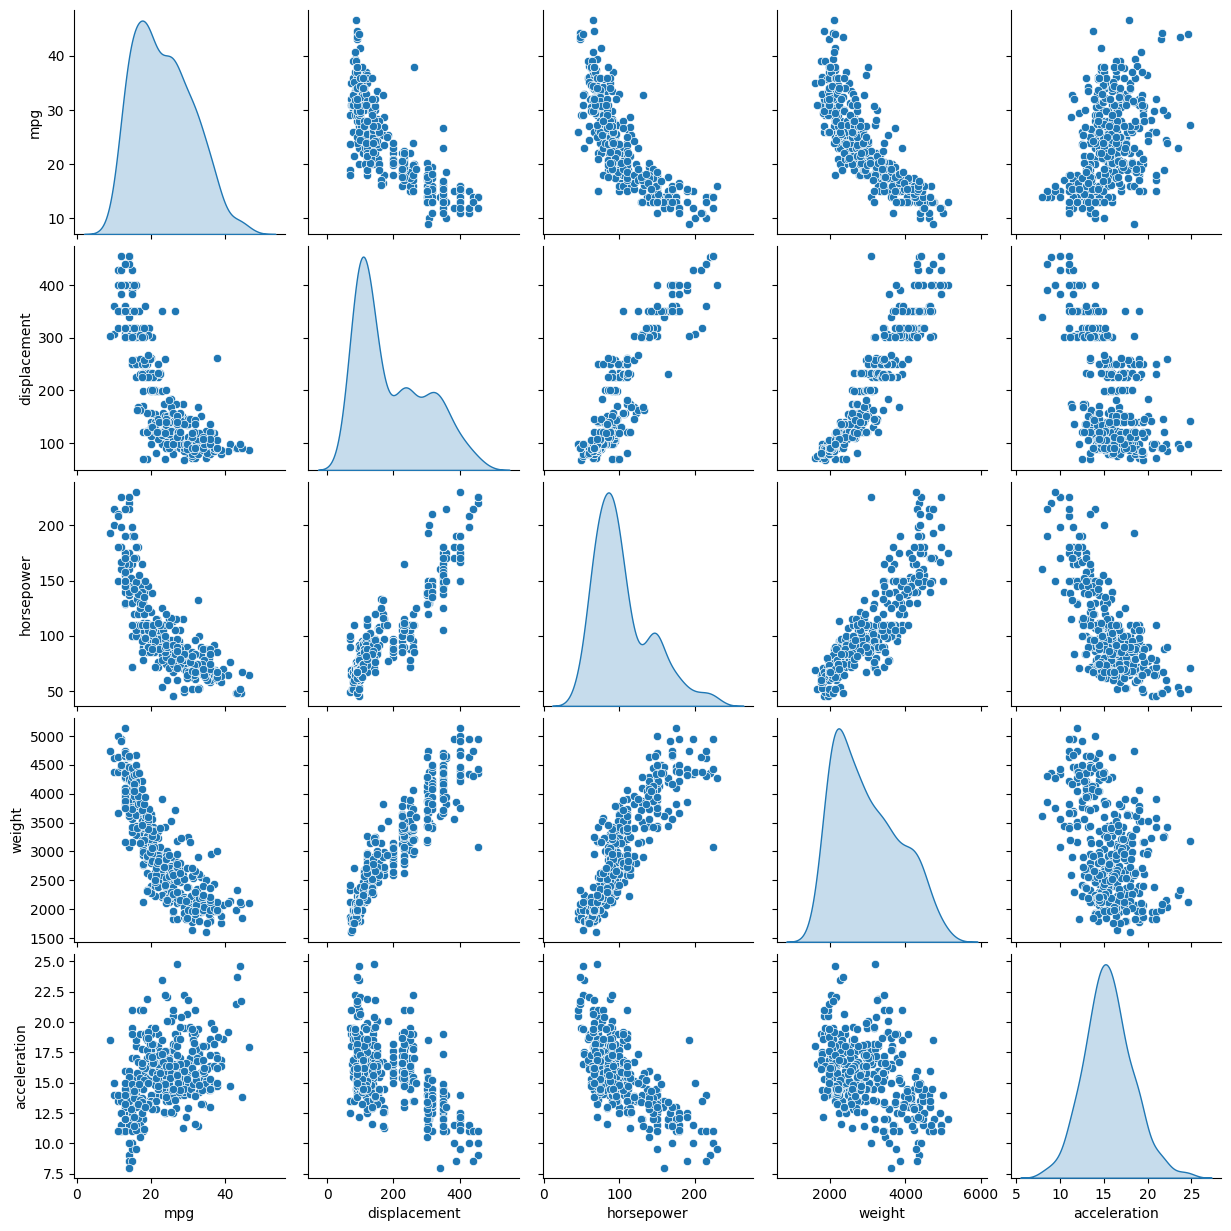

In [3]:
#mpg = mpg[1:][0:len(mpg[:][0])-1]
mpg = np.array(mpg1)

mpg = mpg[0:, 0:len(mpg[0])-1]

print(mpg)
mpg2 = np.asfarray(mpg[1:]) #[float(i) for i in mpg]#.astype(float)
print(mpg2)
newrow = [1.0, 2.0, 3.0, 4.0, 5.0]
mpg2 = np.vstack([newrow, mpg2])

print(mpg2)

mpgdf = pd.DataFrame(mpg2[1:], columns = mpg[0])
sns.pairplot(mpgdf, diag_kind='kde')

If we are using horsepower to predict mpg, which method could lead to the best performance? (Linear Regression, Polynomial Regression, or Logistic Regression) Explain why.

**Answer:** Polynomial Regression would be the best, since the curve looks like a 2nd-order polynomial


## Exercise 2 - Linear and Polynomial Regression (40 points in total)

### Exercise 2.1 - Splitting Dataset (5 points)
Split the data into training and testing set with the ratio of 80:20.

Print the shapes of the training and testing set.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Here we partition our data for Training and Testing

#mpgtargetsdf = pd.DataFrame(mpg.target, columns = ['abc'])

training, testing = train_test_split(mpgdf, test_size=0.2, random_state = 15)
print(training.shape, testing.shape)

(313, 5) (79, 5)


### Exercise 2.2 - Simple Linear Regression (10 points)
Using one of the other attributes(excluding ``origin``) by your choice, please build a simple linear regression model that predicts ``mpg``. <br >

Requirements
 - Report the testing MSE error.

In [5]:
reg = LinearRegression()
xtrain = training.iloc[:, 0:3]
ytrain = training.iloc[:, 4]
xtest = testing.iloc[:, 0:3]
ytest = testing.iloc[:, 4]
regmodel= reg.fit(xtest, ytest)


yhat_train_predict = reg.predict(xtrain)
yhat_test_predict = reg.predict(xtest)
print('\nTrain Mean squared error: %.2f' % mean_squared_error(ytrain, yhat_train_predict))
print('\nTest Mean squared error: %.2f' % mean_squared_error(ytest, yhat_test_predict))


Train Mean squared error: 3.65

Test Mean squared error: 4.41


### Exercise 2.3 - Polynomial Regression (25 points)
Build polynomial regression models that predict ``mpg`` with the same choice in 2.2. <br >
Specifically, from degree=2 to degree=4, build one respectively. <br >
Then, based on the reported errors from only these three degrees, **do you think there is a sign of overfitting? Provide your reasoning.**


Requirements
 - Report the training MSE error for each of the three degrees.
 - Report the testing MSE error for each of the three degrees.


In [30]:
import operator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

reg2 = LinearRegression()
x_poly_train = training.iloc[:, 0:3]
y_train = training.iloc[:, 4]
x_poly_test = testing.iloc[:, 0:3]
y_test = testing.iloc[:, 4]
regmodel= reg.fit(xtest, ytest)



#2
polynomial_features = PolynomialFeatures(degree=2)
x_poly = polynomial_features.fit_transform(mpgdf.iloc[:, 0:4])

x_poly_train, x_poly_test = train_test_split(x_poly, test_size=0.2, random_state = 15)

#print('Polynomial Features: [1,x,x**2]')
#print(x_poly[0])


model = LinearRegression()
model.fit(x_poly_train, y_train)
yhat_train_pred = model.predict(x_poly_train)
yhat_test_pred = model.predict(x_poly_test)

#print("Model weights: ")
#print(model.coef_)


mse = mean_squared_error(y_train,yhat_train_pred)
rmse = np.sqrt(mean_squared_error(y_train,yhat_train_pred))
r2 = r2_score(y_train,yhat_train_pred)
print('Training MSE: %8.15f' % mse)
#print('Training RMSE: %8.15f' % rmse)
#print('Training R2: %8.15f' % r2)

mse = mean_squared_error(y_test,yhat_test_pred)
rmse = np.sqrt(mean_squared_error(y_test,yhat_test_pred))
r2 = r2_score(y_test,yhat_test_pred)
print('Testing MSE: %8.15f' % mse)
#print('Testing RMSE: %8.15f' % rmse)
#print('Testing R2: %8.15f' % r2)








#3
polynomial_features = PolynomialFeatures(degree=3)
x_poly = polynomial_features.fit_transform(mpgdf.iloc[:, 0:4])

x_poly_train, x_poly_test = train_test_split(x_poly, test_size=0.2, random_state = 15)


model = LinearRegression()
model.fit(x_poly_train, y_train)
yhat_train_pred = model.predict(x_poly_train)
yhat_test_pred = model.predict(x_poly_test)


mse = mean_squared_error(y_train,yhat_train_pred)
rmse = np.sqrt(mean_squared_error(y_train,yhat_train_pred))
r2 = r2_score(y_train,yhat_train_pred)
print('Training MSE: %8.15f' % mse)

mse = mean_squared_error(y_test,yhat_test_pred)
rmse = np.sqrt(mean_squared_error(y_test,yhat_test_pred))
r2 = r2_score(y_test,yhat_test_pred)
print('Testing MSE: %8.15f' % mse)





#4
polynomial_features = PolynomialFeatures(degree=4)
x_poly = polynomial_features.fit_transform(mpgdf.iloc[:, 0:4])

x_poly_train, x_poly_test = train_test_split(x_poly, test_size=0.2, random_state = 15)


model = LinearRegression()
model.fit(x_poly_train, y_train)
yhat_train_pred = model.predict(x_poly_train)
yhat_test_pred = model.predict(x_poly_test)


mse = mean_squared_error(y_train,yhat_train_pred)
rmse = np.sqrt(mean_squared_error(y_train,yhat_train_pred))
r2 = r2_score(y_train,yhat_train_pred)
print('Training MSE: %8.15f' % mse)

mse = mean_squared_error(y_test,yhat_test_pred)
rmse = np.sqrt(mean_squared_error(y_test,yhat_test_pred))
r2 = r2_score(y_test,yhat_test_pred)
print('Testing MSE: %8.15f' % mse)






Training MSE: 1.861557211927915
Testing MSE: 2.144277231624544
Training MSE: 1.697580608084046
Testing MSE: 2.946851802440799
Training MSE: 1.028466317603135
Testing MSE: 6.494296536247075


**Answer:** There doesn't seem to be overfitting: the answers got more accurate with each step, but not too much, and aren't that farm barely off of the linear version, so in most cases the countouring caused by the polynomial regression doesn't seem to be causing increased error.
However, the last Testing MSE skyrocketed for unkown reasons, so that should be looked into.

## Exercise 3 - Logistic Regression (35 points in total)

Now we are going to build a classification model on ``origin`` using all the other 5 attributes. <br >
Note that Logistic Regression is a binary classificaiton algorithm.

### Exercise 3.1 - Processing and Splitting the Dataset (5 points)
In this exercise 3, we only consider those observations where they originate from either "USA" or "Japan". <br >
So please **remove** those observations that originate from "Europe". <br >
And then, split the data into training and testing set with the ratio of 80:20. <br >

Print the shapes and the unique values of the training and testing set


In [12]:
from sklearn.linear_model import LogisticRegression

mpg1 = []
with open('hw1/auto-mpg.csv', mode ='r') as file:
  csvFile = csv.reader(file)
  for line in csvFile:
    mpg1.append(line)

#mpg2=mpg1

x=0
while (x < len(mpg1)):
  if mpg1[x][5] == 'Europe':
    #print("a")
    mpg1.pop(x)
    x = x-1
  x = x + 1

mpg = np.array(mpg1)

#mpg = mpg[:, 0:len(mpg[0])-1]

#print(mpg)
#print(mpg[1:])

mpgdf = pd.DataFrame(mpg[1:], columns = mpg[0])

print(mpgdf)


training, testing = train_test_split(mpgdf, test_size=0.2, random_state = 15)
print(training.shape, testing.shape)





      mpg displacement horsepower  weight acceleration origin
0    18.0        307.0      130.0  3504.0         12.0    USA
1    15.0        350.0      165.0  3693.0         11.5    USA
2    18.0        318.0      150.0  3436.0         11.0    USA
3    16.0        304.0      150.0  3433.0         12.0    USA
4    17.0        302.0      140.0  3449.0         10.5    USA
..    ...          ...        ...     ...          ...    ...
319  27.0        151.0       90.0  2950.0         17.3    USA
320  27.0        140.0       86.0  2790.0         15.6    USA
321  32.0        135.0       84.0  2295.0         11.6    USA
322  28.0        120.0       79.0  2625.0         18.6    USA
323  31.0        119.0       82.0  2720.0         19.4    USA

[324 rows x 6 columns]
(259, 6) (65, 6)


### Exercise 3.2 - Logistic Regression (20 points)

Using all the other 5 attributes, please build a Logistic Regression model that distinguishes between cars from Japan and cars from the USA. <br><br>
Now, given the results from models and plots from the previous questions, what do you think a hypothetical model would look like (in terms of accuracy) **if we are distinguishing between Japan and Europe** (instead of Japan and USA)? What would change if anything? Provide your reasoning in the text box below. Feel free to make comparisons based on your previous observations and results.

Requirements
 - Report the testing precision and recall for both regions for the Japan vs. USA model.
 - Provide reasoning for potential difference in accuracy when comparing Japanese and European cars

In [34]:
from sklearn.metrics import classification_report

x_train = training.iloc[:, 0:5]
y_train = training.loc[:, "origin"]
x_test = testing.iloc[:, 0:5]
y_test = testing.loc[:, "origin"]
print(x_train)
print(y_train)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)

yhat_test = logreg.predict(x_test)
yhat_train = logreg.predict(x_train)
yhat_test

logreg.score(x_test, y_test)
logreg.score(x_train, y_train)
yhat_test

print(classification_report(y_test, yhat_test))




      mpg displacement horsepower  weight acceleration
13   14.0        455.0      225.0  3086.0         10.0
79   13.0        440.0      215.0  4735.0         11.0
31   18.0        232.0      100.0  3288.0         15.5
69   27.0         97.0       88.0  2100.0         16.5
7    14.0        440.0      215.0  4312.0          8.5
..    ...          ...        ...     ...          ...
199  39.4         85.0       70.0  2070.0         18.6
155  24.0        200.0       81.0  3012.0         17.6
156  22.5        232.0       90.0  3085.0         17.6
133  15.0        258.0      110.0  3730.0         19.0
245  34.2        105.0       70.0  2200.0         13.2

[259 rows x 5 columns]
13       USA
79       USA
31       USA
69     Japan
7        USA
       ...  
199    Japan
155      USA
156      USA
133      USA
245      USA
Name: origin, Length: 259, dtype: object
              precision    recall  f1-score   support

       Japan       0.63      0.75      0.69        16
         USA       0.91

Now, given the results from models and plots from the previous questions, what do you think a hypothetical model would look like (in terms of accuracy) if we are distinguishing between Japan and Europe (instead of Japan and USA)? What would change if anything? Provide your reasoning in the text box below. Feel free to make comparisons based on your previous observations and results.

**Answer:** I think the model would have about the same accuracy as this one; the models seem to all work fine regardless of the size, and they work pretty well for all data points, so everything should end up just fine. For example, the higher levels of the polynomial reg have similar accuracy.

### Exercise 3.3 - Model coefficients (10 points)

Using all the attributes used in 3.2, plot the model coefficients in a scatter plot as shown in class. Explain the contribution of the top 3 coefficients, and interpret their meaning and their contribution to the $\hat{y}$ prediction. Example can be found [here](https://quantifyinghealth.com/interpret-logistic-regression-coefficients/)

<Axes: >

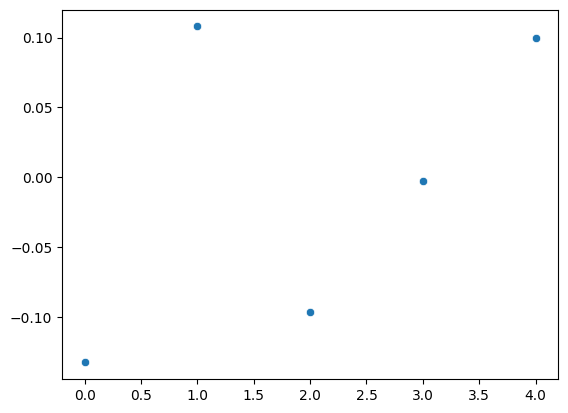

In [35]:
logreg.coef_[0]
sns.scatterplot(x = list(range(0,len(logreg.coef_[0]))),y = logreg.coef_[0])

**Answer:**

This is a graph of log odds vs x; in this case: odds of classifying correctly vs which attribute out of the 5 was picked.
The best attributes are 1.0 (displacement), 4.0 (acceleration), and 3.0 (weight). The more often those values are used as the predictors, the more likely the classification will be correct.

## Exercise 4 - Collaborative Statement (5 points)

It is mandatory to include a Statement of Collaboration in each submission, that follows the guidelines below.
Include the names of everyone involved in the discussions (especially in-person ones), and what was discussed.
All students are required to follow the academic honesty guidelines posted on the course website. For
programming assignments in particular, I encourage students to organize (perhaps using Piazza) to discuss the
task descriptions, requirements, possible bugs in the support code, and the relevant technical content before they
start working on it. However, you should not discuss the specific solutions, and as a guiding principle, you are
not allowed to take anything written or drawn away from these discussions (no photographs of the blackboard,
written notes, referring to Piazza, etc.). Especially after you have started working on the assignment, try to restrict
the discussion to Piazza as much as possible, so that there is no doubt as to the extent of your collaboration.

No collaboration was involved in this assigment